# gRNA (IscB) Denovo Design

Evaluate the quality of IscB ωRNA (guide RNA) variants generated by the finetuned model.

- **Prediction Correlation**: Log-likelihood vs experimental editing efficiency (IscB m16/m17)
- **Structure Rationality**: Pre-computed AF3 structure analysis (BH-RNA, HNH-DNA, RuvC-DNA contacts)
- **Sequence Properties**: Length distribution and sequence similarity

In [1]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import font_manager
from scipy import stats

try:
    import design_paths as DP
except ModuleNotFoundError:
    from notebooks.design import design_paths as DP

GRNA_DATA_DIR = DP.data_dir() / "gRNA"

# Font setup
FONT_PATH = str(DP.font_path())
try:
    font_manager.fontManager.addfont(FONT_PATH)
    plt.rcParams["font.sans-serif"] = ["Arial"]
except:
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["font.weight"] = "normal"

# Figure saving
PIC_DIR = str(DP.figures_dir())
os.makedirs(PIC_DIR, exist_ok=True)

def save_fig(name):
    """Save current figure as 300dpi PNG and SVG with transparent background."""
    plt.savefig(os.path.join(PIC_DIR, f"{name}.png"), format='png', dpi=300,
                bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(PIC_DIR, f"{name}.svg"), format='svg', dpi=300,
                bbox_inches='tight', transparent=True)

## 1. IscB Fitness Prediction

Scatter plots of model log-likelihood vs experimental editing efficiency for IscB m16 and m17 ωRNA systems.

In [2]:
# Load merged prediction data (activity + log-likelihood in one file)
with open(GRNA_DATA_DIR / "iscb_prediction_data.json") as f:
    iscb_data = json.load(f)

iscb_systems = {}
for sys_name in ["m16", "m17"]:
    entries = iscb_data[f"iscb_{sys_name}"]
    activity_list = [e["editing_efficiency"] for e in entries if "editing_efficiency" in e]
    ll_list = [e["log_likelihood"] for e in entries if "editing_efficiency" in e]
    iscb_systems[sys_name] = {"activity": activity_list, "ll": ll_list}

for sys_name in ["m16", "m17"]:
    d = iscb_systems[sys_name]
    rho, pval = stats.pearsonr(d["activity"], d["ll"])
    print(f"IscB {sys_name}: n={len(d['activity'])}, Pearson r={rho:.4f}, p={pval:.4e}")

IscB m16: n=53, Pearson r=0.5474, p=2.2166e-05
IscB m17: n=61, Pearson r=0.6154, p=1.3077e-07


In [3]:
def plot_iscb_correlation(ax, activity, ll, title_text):
    """Scatter plot with regression line and 95% CI."""
    activity = np.array(activity)
    ll = np.array(ll)
    n = len(activity)

    rho, pval = stats.pearsonr(activity, ll)

    # Color map: Blue -> Grey -> Orange
    norm = mcolors.Normalize(vmin=activity.min(), vmax=activity.max())
    colors = [(61/255, 117/255, 176/255), (0.9, 0.9, 0.9), (237/255, 135/255, 51/255)]
    cmap = mcolors.LinearSegmentedColormap.from_list("blue_grey_orange", colors)

    sc = ax.scatter(activity, ll, c=activity, cmap=cmap, norm=norm,
                    s=50, alpha=0.9, edgecolors="none", zorder=3)

    # Linear regression + 95% CI
    slope, intercept, *_ = stats.linregress(activity, ll)
    x_sorted = np.linspace(activity.min(), activity.max(), 200)
    y_hat = slope * x_sorted + intercept

    residuals = ll - (slope * activity + intercept)
    std_err_est = np.sqrt(np.sum(residuals**2) / (n - 2)) if n > 2 else 0
    x_mean = activity.mean()
    sxx = np.sum((activity - x_mean)**2)
    se_line = std_err_est * np.sqrt(1.0/n + (x_sorted - x_mean)**2 / sxx)
    t_val = stats.t.ppf(0.975, df=n - 2)
    ci = t_val * se_line

    ax.plot(x_sorted, y_hat, color="black", ls="--", lw=1.5, zorder=4, label="Linear Regression")
    ax.fill_between(x_sorted, y_hat - ci, y_hat + ci,
                    color="grey", alpha=0.3, zorder=2, linewidth=0, label="95% Confidence Interval")

    ax.set_xlabel("Editing Efficiency", fontsize=14)
    ax.set_ylabel("Log-Likelihood", fontsize=14)
    ax.set_title(f"Pearson: {rho:.2f}\n{title_text}", fontsize=16, fontweight="normal")
    ax.tick_params(axis="both", which="major", labelsize=12)

    legend = ax.legend(loc="lower right", fontsize=11, frameon=True, fancybox=True)
    legend.get_frame().set_alpha(0.9)
    legend.get_frame().set_facecolor('white')
    return sc

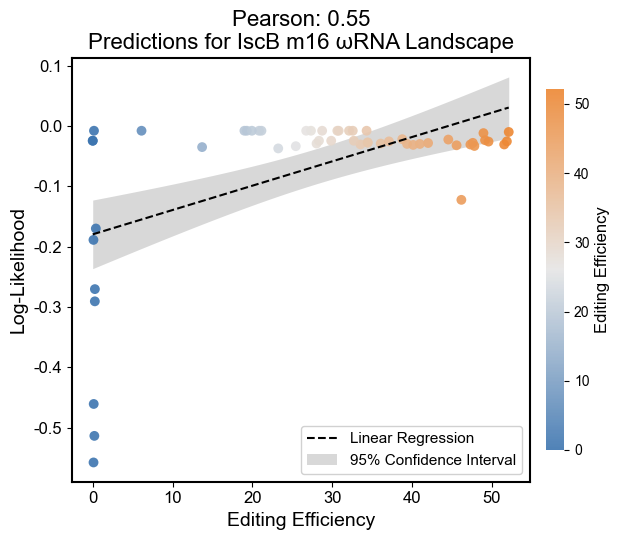

In [4]:
# IscB m16
fig, ax = plt.subplots(figsize=(6.5, 5.5))
d = iscb_systems["m16"]
sc = plot_iscb_correlation(ax, d["activity"], d["ll"], "Predictions for IscB m16 \u03c9RNA Landscape")
cbar = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label("Editing Efficiency", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_visible(False)
plt.tight_layout()
save_fig("gRNA_iscb_m16_correlation")
plt.show()

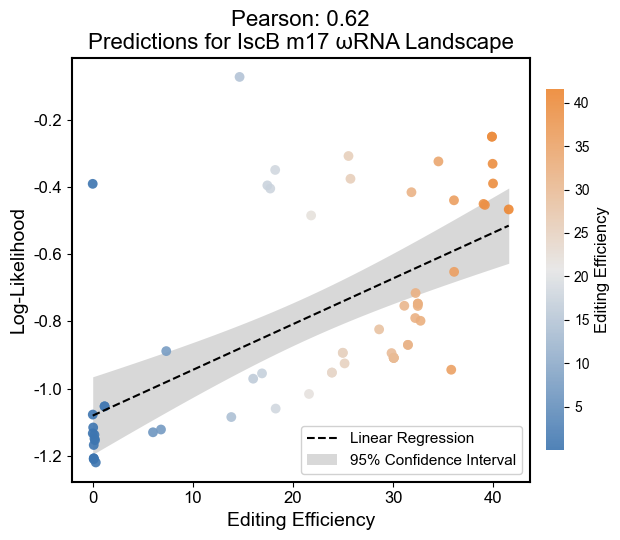

In [5]:
# IscB m17
fig, ax = plt.subplots(figsize=(6.5, 5.5))
d = iscb_systems["m17"]
sc = plot_iscb_correlation(ax, d["activity"], d["ll"], "Predictions for IscB m17 \u03c9RNA Landscape")
cbar = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label("Editing Efficiency", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_visible(False)
plt.tight_layout()
save_fig("gRNA_iscb_m17_correlation")
plt.show()

## 2. Structure Rationality Analysis

Pre-computed AF3 structure analysis results. Metrics include BH-RNA wrapping, HNH-targetDNA contact, and RuvC-nontargetDNA contact at multiple distance thresholds.

In [ ]:
# Load structure analysis results
df_struct = pd.read_csv(GRNA_DATA_DIR / "structure_analysis_summary.csv")

# Drop PLMP-related columns (keep values for composite score recomputation)
plmp_cols = [c for c in df_struct.columns if 'plmp' in c.lower() or 'PLMP' in c]

# Recompute composite score with correct formula
COMPOSITE_WEIGHTS = {
    "bh_rna_coverage_7A": 0.250,
    "plmp_ruvc_coverage_7A": 0.150,
    "plmp_rna_coverage_7A": 0.150,
    "hnh_targetdna_coverage_7A": 0.225,
    "ruvc_nontargetdna_coverage_7A": 0.225,
}

def compute_composite(row):
    score = sum(w * (row.get(c, 0.0) or 0.0) for c, w in COMPOSITE_WEIGHTS.items())
    ranking = row.get("ranking_score", 0.0) or 0.0
    return round(score * (0.5 + 0.5 * ranking), 4)

df_struct["composite_score"] = df_struct.apply(compute_composite, axis=1)

# Pass/fail thresholds at 7Å (reference structure values)
# HNH-TargetDNA and WED-PAM use 90% of reference; others use 100%
PASS_THRESHOLDS = {
    "bh_rna_coverage_7A":              0.6579,  # 100% of ref
    "hnh_targetdna_coverage_7A":       0.2495,  # 90% of ref (0.2772)
    "ruvc_nontargetdna_coverage_7A":   0.1014,  # 100% of ref
}
# WED-PAM threshold (applied when column exists)
WED_PAM_THRESHOLD = 0.1200  # 90% of ref (0.1333)

# Print pass rates
n = len(df_struct)
print(f"Loaded {n} structures")
for col, thr in PASS_THRESHOLDS.items():
    n_pass = (df_struct[col] >= thr).sum()
    print(f"  {col}: {n_pass}/{n} ({100*n_pass/n:.1f}%) >= {thr}")

if "wed_pam_coverage_7A" in df_struct.columns:
    n_pass = (df_struct["wed_pam_coverage_7A"] >= WED_PAM_THRESHOLD).sum()
    print(f"  wed_pam_coverage_7A: {n_pass}/{n} ({100*n_pass/n:.1f}%) >= {WED_PAM_THRESHOLD}")

# Composite score stats
ref_composite = 0.2025
n_pass_comp = (df_struct["composite_score"] >= ref_composite).sum()
print(f"  composite_score: {n_pass_comp}/{n} ({100*n_pass_comp/n:.1f}%) >= {ref_composite}")

# Now drop PLMP columns for display
df_struct = df_struct.drop(columns=plmp_cols)
print(f"\nColumns for analysis: {len(df_struct.columns)} (PLMP dropped)")

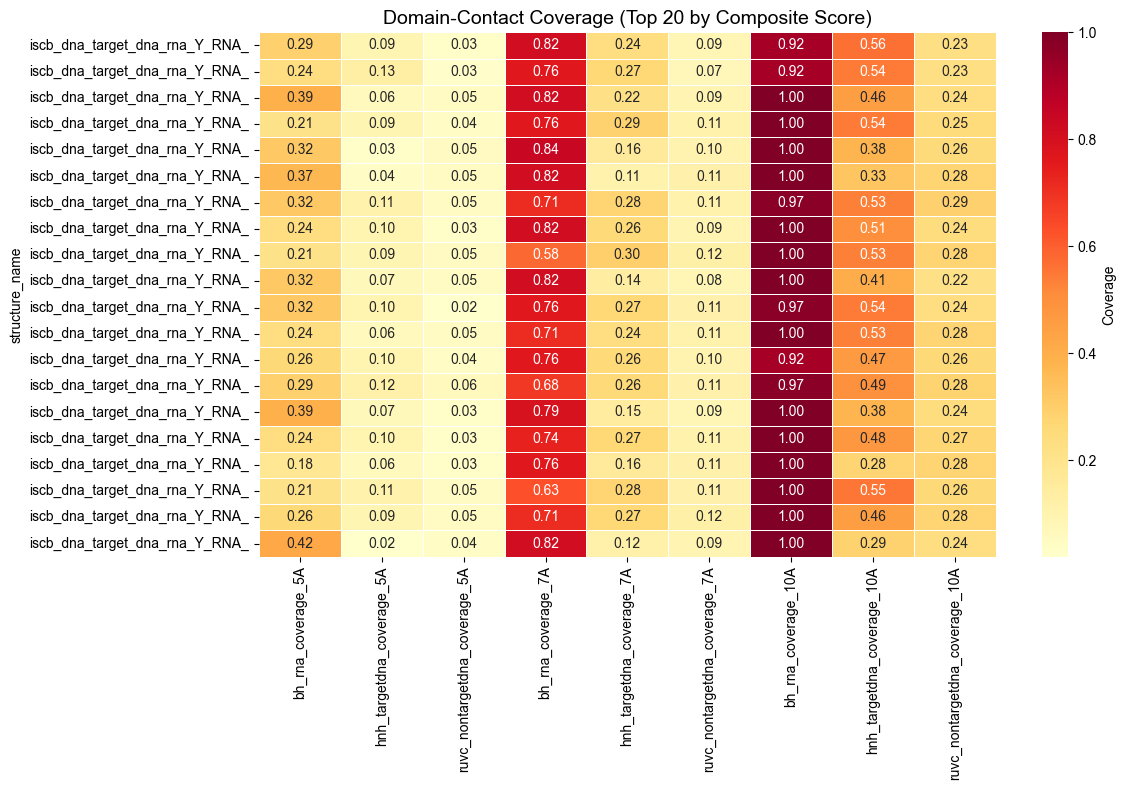

In [7]:
# Coverage heatmap
coverage_cols = [c for c in df_struct.columns if 'coverage' in c]
if coverage_cols:
    # Show top 20 by composite_score
    if 'composite_score' in df_struct.columns:
        df_top = df_struct.nlargest(20, 'composite_score')
    else:
        df_top = df_struct.head(20)

    df_cov = df_top[coverage_cols].copy()
    if 'structure_name' in df_top.columns:
        df_cov.index = df_top['structure_name'].str[:30]

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(df_cov, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Coverage'})
    ax.set_title('Domain-Contact Coverage (Top 20 by Composite Score)', fontsize=14)
    plt.tight_layout()
    save_fig("gRNA_coverage_heatmap")
    plt.show()

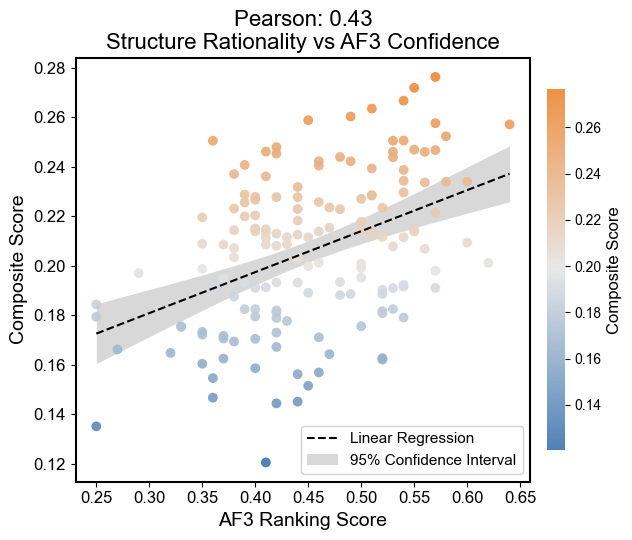

In [8]:
# Composite score vs AF3 ranking score
if 'composite_score' in df_struct.columns and 'ranking_score' in df_struct.columns:
    x = df_struct['ranking_score'].values
    y = df_struct['composite_score'].values

    rho, pval = stats.pearsonr(x, y)

    # Color map: Blue -> Grey -> Orange
    norm = mcolors.Normalize(vmin=y.min(), vmax=y.max())
    colors = [(61/255, 117/255, 176/255), (0.9, 0.9, 0.9), (237/255, 135/255, 51/255)]
    cmap = mcolors.LinearSegmentedColormap.from_list("blue_grey_orange", colors)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sc = ax.scatter(x, y, c=y, cmap=cmap, norm=norm,
                    s=50, alpha=0.9, edgecolors="none", zorder=3)

    # Linear regression + 95% CI
    n = len(x)
    slope, intercept, *_ = stats.linregress(x, y)
    x_sorted = np.linspace(x.min(), x.max(), 200)
    y_hat = slope * x_sorted + intercept

    residuals = y - (slope * x + intercept)
    std_err_est = np.sqrt(np.sum(residuals**2) / (n - 2)) if n > 2 else 0
    x_mean = x.mean()
    sxx = np.sum((x - x_mean)**2)
    se_line = std_err_est * np.sqrt(1.0/n + (x_sorted - x_mean)**2 / sxx)
    t_val = stats.t.ppf(0.975, df=n - 2)
    ci = t_val * se_line

    ax.plot(x_sorted, y_hat, color="black", ls="--", lw=1.5, zorder=4, label="Linear Regression")
    ax.fill_between(x_sorted, y_hat - ci, y_hat + ci,
                    color="grey", alpha=0.3, zorder=2, linewidth=0, label="95% Confidence Interval")

    ax.set_xlabel('AF3 Ranking Score', fontsize=14)
    ax.set_ylabel('Composite Score', fontsize=14)
    ax.set_title(f'Pearson: {rho:.2f}\nStructure Rationality vs AF3 Confidence', fontsize=16, fontweight="normal")
    ax.tick_params(axis='both', which='major', labelsize=12)

    legend = ax.legend(loc="lower right", fontsize=11, frameon=True, fancybox=True)
    legend.get_frame().set_alpha(0.9)
    legend.get_frame().set_facecolor('white')

    cbar = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.03)
    cbar.set_label("Composite Score", fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    cbar.outline.set_visible(False)
    plt.tight_layout()
    save_fig("gRNA_structure_vs_af3")
    plt.show()

## 4. Sequence Properties

### 4.1 Length Distribution

In [14]:
plt.rcParams["axes.linewidth"] = 2.0

WILDTYPE_LENGTH = 195
MIN_LEN, MAX_LEN = 145, 216


def parse_fasta_lengths(fasta_path, spacer_len=16):
    """Parse FASTA and return sequence lengths (+ spacer)."""
    lengths = []
    seq = ""
    with open(fasta_path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if seq:
                    lengths.append(len(seq) + spacer_len)
                    seq = ""
            else:
                seq += line
        if seq:
            lengths.append(len(seq) + spacer_len)
    return lengths


def plot_length_dist(lengths, title, wildtype_length=195, min_len=145, max_len=216, save_name=None):
    """Violin plot of sequence length distribution."""
    filtered = [l for l in lengths if min_len <= l <= max_len]
    print(f"Total: {len(lengths)}, Filtered ({min_len}-{max_len} nt): {len(filtered)}")

    df = pd.DataFrame({'Sequence Length (nt)': filtered, 'Category': 'Generated \u03c9RNA'})

    plt.figure(figsize=(5, 6))
    sns.set_style("ticks")
    ax = sns.violinplot(data=df, x="Category", y="Sequence Length (nt)",
                        color="#f5a65b", inner="box", linewidth=1.5, cut=0)

    ax.axhline(y=wildtype_length, xmin=0.35, xmax=0.65, color='#8B0000', linestyle='--', linewidth=2.0)
    ax.text(0.66, wildtype_length, f'Wildtype ({wildtype_length} nt)',
            transform=ax.get_yaxis_transform(), va='center', ha='left', fontsize=12, color='#8B0000')

    plt.title(title, fontsize=18, pad=20)
    plt.ylabel("Sequence Length (nt)", fontsize=16)
    plt.xlabel("")
    ax.tick_params(axis='both', which='major', labelsize=14, width=2.0, length=6)
    sns.despine()
    plt.tight_layout()
    if save_name:
        save_fig(save_name)
    plt.show()

Total: 1800, Filtered (145-216 nt): 1603


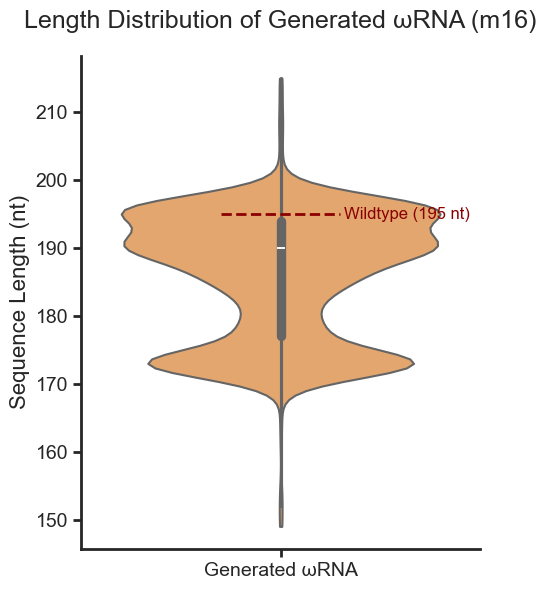

In [15]:
# m16 length distribution
lengths_m16 = parse_fasta_lengths(GRNA_DATA_DIR / "grna_m16_1800_merged.fasta")
plot_length_dist(lengths_m16, "Length Distribution of Generated \u03c9RNA (m16)",
                 save_name="gRNA_m16_length_dist")

Total: 1595, Filtered (190-250 nt): 789


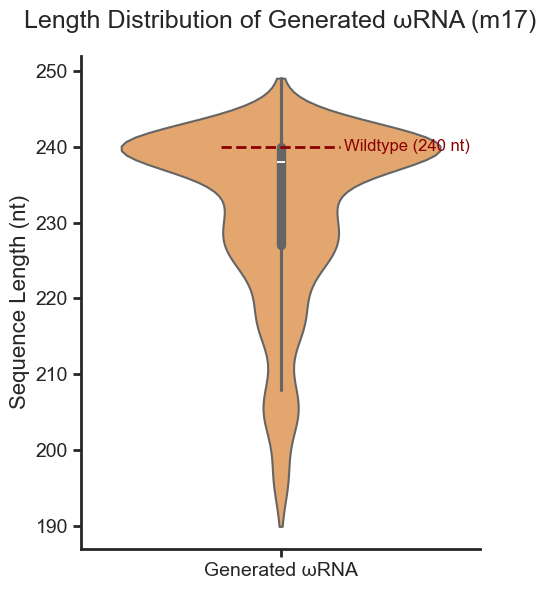

In [16]:
# m17 length distribution
lengths_m17 = parse_fasta_lengths(GRNA_DATA_DIR / "grna_m17_1600_merged.fasta")
plot_length_dist(lengths_m17, "Length Distribution of Generated \u03c9RNA (m17)",
                 wildtype_length=240, min_len=190, max_len=250,
                 save_name="gRNA_m17_length_dist")

### 4.2 Sequence Similarity

Count: 1800, Range: 0.041-0.989, Mean: 0.858, Median: 0.928


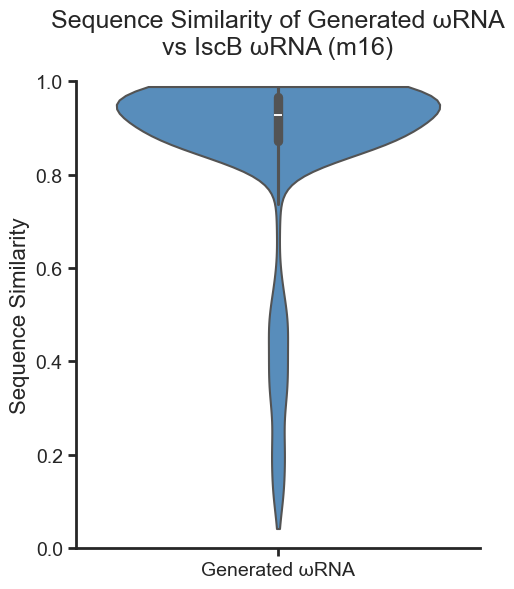

In [18]:
def plot_seq_similarity(filepath, title, save_name=None):
    """Violin plot of sequence similarity."""
    with open(filepath) as f:
        sims = [float(line.strip()) for line in f if line.strip()]

    df = pd.DataFrame({'Sequence Similarity': sims, 'Category': 'Generated \u03c9RNA'})
    print(f"Count: {len(sims)}, Range: {min(sims):.3f}-{max(sims):.3f}, "
          f"Mean: {np.mean(sims):.3f}, Median: {np.median(sims):.3f}")

    plt.figure(figsize=(5, 6))
    sns.set_style("ticks")
    ax = sns.violinplot(data=df, x="Category", y="Sequence Similarity",
                        color="#478ecc", inner="box", linewidth=1.5, cut=0)
    plt.title(title, fontsize=18, pad=20)
    plt.ylabel("Sequence Similarity", fontsize=16)
    plt.xlabel("")
    ax.tick_params(axis='both', which='major', labelsize=14, width=2.0, length=6)
    plt.ylim(0, 1.0)
    sns.despine()
    plt.tight_layout()
    if save_name:
        save_fig(save_name)
    plt.show()


# m16
plot_seq_similarity(GRNA_DATA_DIR / "m16_sequence_similarity.txt",
                    "Sequence Similarity of Generated \u03c9RNA\nvs IscB \u03c9RNA (m16)",
                    save_name="gRNA_m16_seq_similarity")

Count: 1595, Range: 0.094-1.000, Mean: 0.827, Median: 0.737


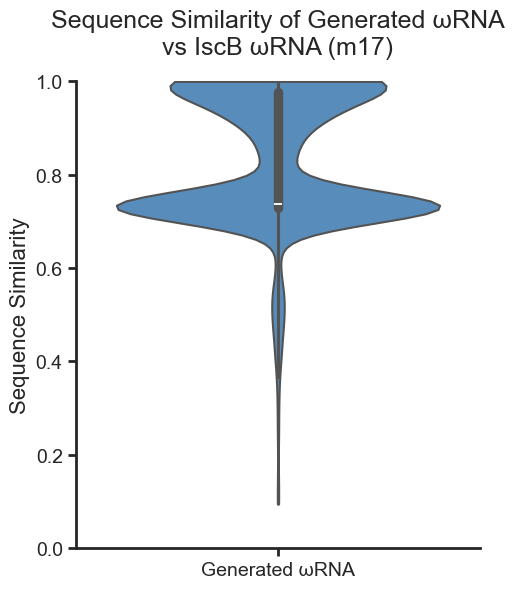

In [19]:
# m17
plot_seq_similarity(GRNA_DATA_DIR / "m17_sequence_similarity.txt",
                    "Sequence Similarity of Generated \u03c9RNA\nvs IscB \u03c9RNA (m17)",
                    save_name="gRNA_m17_seq_similarity")